# Associação entre SO₂ e PM10 em Cubatão-Vila Parisi

Análise observacional informada por inferência causal da relação entre dióxido de enxofre (SO₂, marcador de emissão industrial) e material particulado (PM10) na estação Cubatão-Vila Parisi (2021–2022).

Este notebook é reprodutível de ponta a ponta: lê os dados diretamente do repositório e reproduz todos os resultados do estudo. Fonte dos dados: OpenAQ/CETESB (poluentes) e Open-Meteo (meteorologia).

**Resultado principal:** associação contemporânea de 0,4481 µg/m³ de PM10 por µg/m³ de SO₂ (IC 95% HAC: 0,1756–0,7207; p = 1,27×10⁻³), interpretada como compatível com co-emissão industrial — não como efeito causal direto.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox

BASE = "https://raw.githubusercontent.com/bpreschad-gif/aquvaris-causal-environmental-research/main/data"
URL_POL = f"{BASE}/cubatao_industrial_20260708_120559.parquet"
URL_MET = f"{BASE}/meteo_cubatao_2021_2022.parquet"

pol = pd.read_parquet(URL_POL)
met = pd.read_parquet(URL_MET)
print("Poluentes:", pol.shape, "| Meteorologia:", met.shape)
print("Estações:", pol["estacao"].unique().tolist())

Poluentes: (1399, 5) | Meteorologia: (730, 8)
Estações: ['Cubatão-V.Parisi', 'Cubatão-Vale do Mogi']


## 1. Preparação da base

Foco na estação Cubatão-V.Parisi. Valores ≤ 0 são tratados como ausentes (fisicamente implausíveis em ambiente urbano). Juntamos os poluentes à meteorologia por data e adicionamos indicadores de sazonalidade (mês) e tendência temporal.


In [8]:
pol["data"] = pd.to_datetime(pol["data"])
met["data"] = pd.to_datetime(met["data"])

vp = pol[pol["estacao"] == "Cubatão-V.Parisi"].copy()
for c in ["so2", "pm10", "no2"]:
    vp.loc[vp[c] <= 0, c] = np.nan

base = vp.merge(met, on="data", how="left").sort_values("data").reset_index(drop=True)
base["mes"] = base["data"].dt.month.astype("category")
base["tend"] = (base["data"] - base["data"].min()).dt.days

d = base[["so2","pm10","no2","temp_media","chuva_mm","vento_max",
          "umidade","pressao","mes","tend"]].dropna()
print("Dias completos na análise:", len(d))
print("Período:", base["data"].min().date(), "->", base["data"].max().date())

Dias completos na análise: 605
Período: 2021-01-12 -> 2022-12-31


## 2. Exploração das séries

As três séries diárias ao longo de 2021–2022. Note o padrão episódico do SO₂ (picos isolados, típicos de emissão industrial pontual) contra a variação mais contínua do PM10.

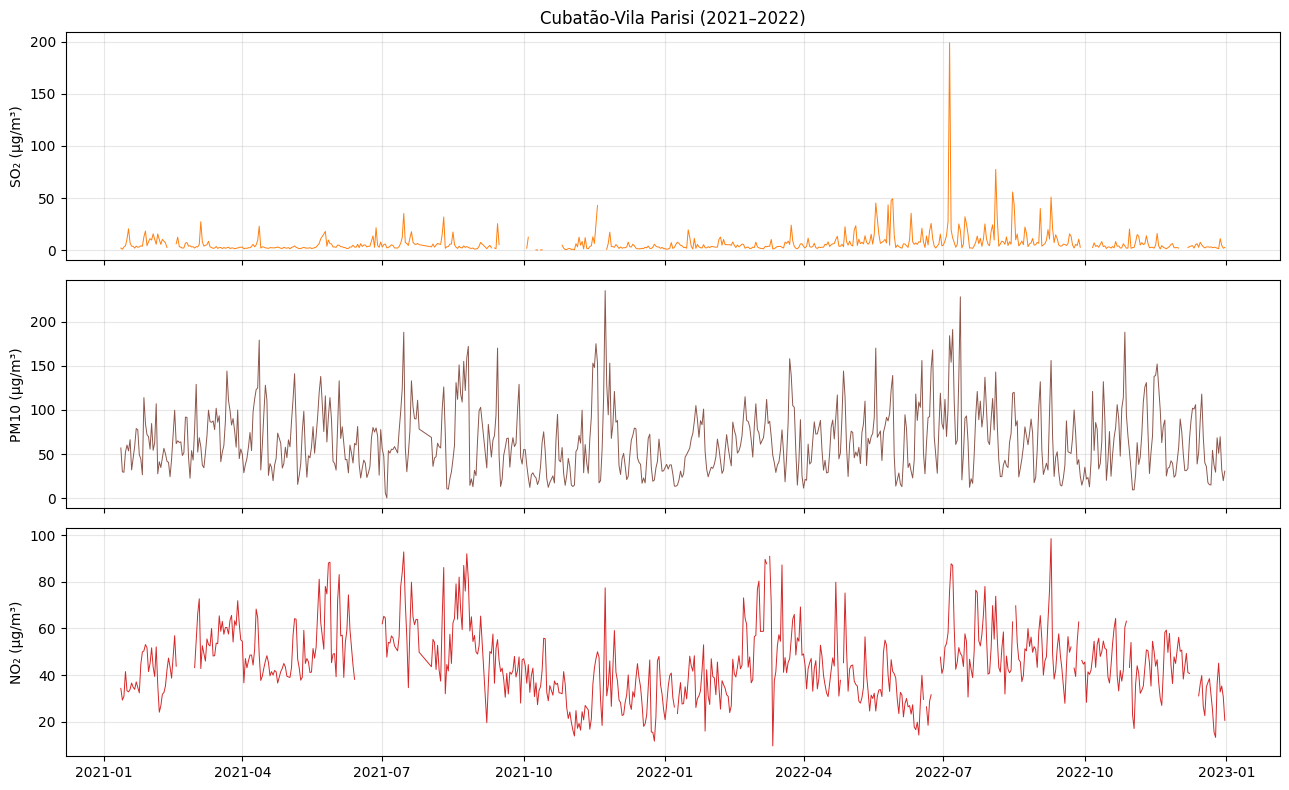

Correlação SO2-NO2: 0.1927


In [9]:
bi = base.set_index("data")
fig, ax = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
ax[0].plot(bi.index, bi["so2"], color="tab:orange", lw=0.7)
ax[0].set_ylabel("SO₂ (µg/m³)"); ax[0].set_title("Cubatão-Vila Parisi (2021–2022)"); ax[0].grid(alpha=0.3)
ax[1].plot(bi.index, bi["pm10"], color="tab:brown", lw=0.7)
ax[1].set_ylabel("PM10 (µg/m³)"); ax[1].grid(alpha=0.3)
ax[2].plot(bi.index, bi["no2"], color="tab:red", lw=0.7)
ax[2].set_ylabel("NO₂ (µg/m³)"); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Correlação SO2-NO2:", round(d["so2"].corr(d["no2"]), 4))

## 3. Modelo principal

Regressão de PM10 sobre SO₂, ajustando por meteorologia, NO₂ (tráfego), sazonalidade (mês) e tendência. A baixa correlação SO₂–NO₂ (~0,19) apoia tratar NO₂ como confundidor, não como co-emissor dominante.

In [10]:
formula = "pm10 ~ so2 + no2 + temp_media + chuva_mm + vento_max + umidade + pressao + C(mes) + tend"
m = smf.ols(formula, data=d).fit()
print("Efeito SO2:", round(m.params["so2"], 4))
print("IC95% (OLS):", [round(x,4) for x in m.conf_int().loc["so2"]])
print("R²:", round(m.rsquared, 4), "| R² ajustado:", round(m.rsquared_adj, 4))
print("N:", int(m.nobs))

Efeito SO2: 0.4481
IC95% (OLS): [0.2386, 0.6576]
R²: 0.5492 | R² ajustado: 0.5346
N: 605


## 4. Estrutura temporal

Três especificações para investigar a direção temporal do sinal:
- **t+1 → t (placebo):** SO₂ de amanhã "explicando" PM10 de hoje. Deveria ser nulo.
- **t → t (contemporâneo):** mesmo dia.
- **t−1 → t (defasado):** SO₂ de ontem sobre PM10 de hoje.
Defasagens construídas por data-calendário (não por posição de linha), para não cruzar lacunas na série.


In [11]:
so2d = base[["data","so2"]].dropna()
lag  = so2d.copy(); lag["data"]  = lag["data"]  + pd.Timedelta(days=1); lag  = lag.rename(columns={"so2":"so2_lag1"})
lead = so2d.copy(); lead["data"] = lead["data"] - pd.Timedelta(days=1); lead = lead.rename(columns={"so2":"so2_lead1"})
bt = base.merge(lag, on="data", how="left").merge(lead, on="data", how="left")

conf = "no2 + temp_media + chuva_mm + vento_max + umidade + pressao + C(mes) + tend"
def eff(t):
    dd = bt[[t,"pm10","no2","temp_media","chuva_mm","vento_max","umidade","pressao","mes","tend"]].dropna()
    mm = smf.ols(f"pm10 ~ {t} + {conf}", data=dd).fit()
    ic = mm.conf_int().loc[t]
    return {"espec": t, "beta": round(mm.params[t],4),
            "IC_inf": round(ic[0],4), "IC_sup": round(ic[1],4),
            "p": f"{mm.pvalues[t]:.2e}", "N": int(mm.nobs)}

print(pd.DataFrame([eff("so2_lead1"), eff("so2"), eff("so2_lag1")]).to_string(index=False))

    espec   beta  IC_inf  IC_sup        p   N
so2_lead1 0.2071  0.0101  0.4041 3.94e-02 599
      so2 0.4481  0.2386  0.6576 3.07e-05 605
 so2_lag1 0.0850 -0.1125  0.2824 3.98e-01 598


## 5. Diagnóstico de resíduos e inferência robusta

Séries temporais violam a independência dos resíduos assumida pela regressão comum. Testamos e, confirmada a autocorrelação, adotamos erros-padrão HAC (Newey-West), que corrigem a incerteza sem alterar a estimativa pontual.


In [12]:
print("=== DIAGNÓSTICO DE RESÍDUOS ===")
print("Durbin-Watson:", round(durbin_watson(m.resid), 3), "(2 = sem autocorrelação)")
lb = acorr_ljungbox(m.resid, lags=[1,7], return_df=True)
print("Ljung-Box p (lag1, lag7):", [f"{p:.2e}" for p in lb["lb_pvalue"]])
bp = het_breuschpagan(m.resid, m.model.exog)
print("Breusch-Pagan p:", f"{bp[1]:.2e}")

print("\n=== INFERÊNCIA HAC (sensibilidade ao maxlags) ===")
for ml in [7, 8]:
    mh = smf.ols(formula, data=d).fit(cov_type="HAC", cov_kwds={"maxlags": ml})
    ic = mh.conf_int().loc["so2"]
    print(f"HAC-{ml}: beta={mh.params['so2']:.4f} | IC95%=[{ic[0]:.4f}, {ic[1]:.4f}] | p={mh.pvalues['so2']:.2e}")

=== DIAGNÓSTICO DE RESÍDUOS ===
Durbin-Watson: 1.271 (2 = sem autocorrelação)
Ljung-Box p (lag1, lag7): ['2.54e-19', '1.07e-21']
Breusch-Pagan p: 1.07e-05

=== INFERÊNCIA HAC (sensibilidade ao maxlags) ===
HAC-7: beta=0.4481 | IC95%=[0.1756, 0.7207] | p=1.27e-03
HAC-8: beta=0.4481 | IC95%=[0.1714, 0.7248] | p=1.50e-03


## Conclusão

Associação contemporânea robusta de **0,4481 µg/m³ de PM10 por µg/m³ de SO₂** (IC 95% HAC-7: 0,1756–0,7207; p = 1,27×10⁻³), estável ao controle de meteorologia, sazonalidade, tendência e tráfego, e à escolha do parâmetro de inferência.

A defasada de um dia é nula e o efeito concentra-se no mesmo dia: padrão **compatível com co-emissão por fonte industrial comum**. A estrutura contemporânea não distingue co-emissão de conversão química rápida; portanto, o resultado é reportado como **associação ajustada**, não como efeito causal direto SO₂→PM10.

**O que esta análise estabelece:** uma associação quantificada, robusta e auditável, com incerteza corretamente estimada.
**O que esta análise NÃO estabelece:** atribuição causal de fonte; o mecanismo exato (co-emissão vs. conversão); generalização para além desta estação e período.

Repositório completo, paper e limitações: github.com/bpreschad-gif/aquvaris-causal-environmental-research